## Simple MULTI Agent

In [ ]:
from typing import Annotated, List, Literal
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
import os 
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [ ]:
from langgraph.graph import END, START, MessagesState
from langgraph.graph.state import StateGraph

class AgentState(MessagesState):
    messages : Annotated[list[dict], add_messages]
    next_agent: str
    research_data : str | None
    tool_round: int = 0

In [ ]:
from langchain_tavily import TavilySearch
import requests
import arxiv

from langgraph.types import Command, interrupt


# Tavily client (existing)
tavily_client = TavilySearch(max_results=3)

@tool
def search_web(query: str) -> str:
    """
    Search the web using Tavily for current information.
    
    Args:
        query (str): The search query to look up information about
        
    Returns:
        str: Search results with relevant information
    """
    try:
        results = tavily_client.invoke(query)
        if isinstance(results, list) and len(results) > 0:
            formatted_results = []
            for i, result in enumerate(results[:3], 1):
                if isinstance(result, dict):
                    title = result.get('title', 'No title')
                    content = result.get('content', 'No content')
                    url = result.get('url', 'No URL')
                    formatted_results.append(f"{i}. {title}\n   {content[:200]}...\n   Source: {url}")
                else:
                    formatted_results.append(f"{i}. {str(result)[:200]}...")
            return "\n\n".join(formatted_results)
        else:
            return f"Search results for '{query}': {str(results)[:500]}"
    except Exception as e:
        return f"Search failed: {str(e)}"


# New: simple arXiv searcher using arXiv API (via query)
@tool
def arxiv_search(query: str, max_results: int = 3) -> str:
    """
    Search arXiv using the arxiv package and return titles + abstracts + PDF links.
    """
    try:
        search = arxiv.Search(query=query, max_results=max_results, sort_by=arxiv.SortCriterion.Relevance)
        parsed = []
        for result in search.results():
            title = result.title or "No title"
            summary = (result.summary or "No summary").strip()
            pdf_url = result.pdf_url or (result.entry_id if hasattr(result, "entry_id") else "No link")
            parsed.append(f"- {title}\n  {summary[:500]}...\n  {pdf_url}")
        return "\n\n".join(parsed) if parsed else "No results"
    except Exception as e:
        return f"arXiv search failed: {e}"


@tool
def write_summary(text: str) -> str:
    """
    Write a concise summary of the provided text.
    
    Args:
        text (str): The text to summarize
        
    Returns:
        str: A concise summary of the text
    """
    summary = f"Summary: {text[:500]}..."  # Simple placeholder
    return summary


# Human-in-the-loop assistance tool using interrupt
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human. This will pause execution until a human provides input via a Command."""
    human_response = interrupt({"query": query})
    return human_response.get("data", "")

tools = [search_web, arxiv_search, human_assistance]

In [ ]:

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x72724431a0e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x72724431b370>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
def researcher_agent(state: AgentState):
    messages = state["messages"]
    researcher = llm.bind_tools([search_web, arxiv_search])

    system_msg = SystemMessage(
    content=(
        "You are a research assistant. If you need external data, select exactly ONE tool "
        "from [search_web, arxiv_search] and call it exactly once. Do NOT chain multiple "
        "tool calls in a single reply. If you can answer without tools, do so. "
        "Return the final answer as the assistant content."
    )
)

    # Prevent infinite tool-researcher loops by bounding tool rounds
    MAX_TOOL_ROUNDS = 2
    current_round = state.get("tool_round", 0)

    # If we've already hit the max rounds, avoid calling tools again — fall back to direct LLM
    if current_round >= MAX_TOOL_ROUNDS:
        res = llm.invoke(messages + [system_msg])
        content = getattr(res, "content", str(res))
        return {"messages": [res], "research_data": content}

    # Otherwise allow tools (this may cause the ToolNode to run and later return to researcher)
    res = researcher.invoke(messages + [system_msg])
    content = getattr(res, "content", str(res))

    # increment tool_round if the tool was used (simple heuristic: check for tool_calls on the response)
    try:
        used_tool = False
        if hasattr(res, "tool_calls") and res.tool_calls:
            used_tool = True
    except Exception:
        used_tool = False

    new_round = current_round + (1 if used_tool else 0)

    return {"messages": [res], "research_data": content, "tool_round": new_round}

In [ ]:
def writer_agent(state: AgentState):
    messages = state["messages"]
    system_msg = SystemMessage(content="You are a concise writer. Summarize the research.")
    res = llm.invoke(messages + [system_msg])
    return {"messages": [res]}

In [37]:
# def execute_tools(state: AgentState):
#     """Execute tools based on the current agent."""
    
#     messages = state["messages"]
#     last_message = messages[-1] if messages else None   
    
#     if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
#         tool_node = ToolNode([search_web, write_summary])
#         response = tool_node.invoke(state)
        
    
#     return state

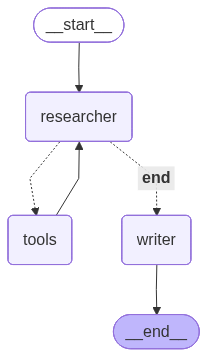

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(AgentState)

tool_node = ToolNode(tools)

# Add nodes
workflow.set_entry_point("researcher")
workflow.add_node("researcher", researcher_agent)
workflow.add_node("tools", tool_node)
workflow.add_node("writer", writer_agent)

# Add routing: researcher → (tools OR writer) using tools_condition
workflow.add_conditional_edges(
    "researcher",
    tools_condition,
    {"tools": "tools", "__end__": "writer"}  # if tool calls exist → go to tools, else → writer
)

# After tool execution, go back to researcher so we can allow iterations (bounded by tool_round)
workflow.add_edge("tools", "researcher")

# Finally, writer → END
workflow.add_edge("writer", END)

compiled = workflow.compile()

compiled

In [ ]:
response = compiled.invoke({
    "messages": [HumanMessage(content="Latest papers in vision models ?")]
})

/tmp/ipykernel_726434/1120855142.py:50: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for result in search.results():


In [97]:
response

{'messages': [HumanMessage(content='Latest papers in vision models ?', additional_kwargs={}, response_metadata={}, id='978d81d6-288a-4e4e-b915-419f735ec14e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fc_0d2372e6-e231-488b-b2b1-90ba75b232e1', 'function': {'arguments': '{"query":"latest papers vision models 2025"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 270, 'total_tokens': 334, 'completion_time': 0.074148869, 'prompt_time': 6.8979e-05, 'queue_time': 0.045799391, 'total_time': 0.074217848, 'prompt_tokens_details': {'cached_tokens': 256}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--b2ef5aad-77f1-4753-8245-f989f31ea5d9-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'latest papers vision models 2025'}, 'id': 'fc_0d2372e6-e231-488b-b2b1-90ba75b232e1', 'type': 'tool_call'}], usage_meta

In [ ]:
response["messages"][-1]

## Supervise Multi Agent Workflows

In [45]:
from typing import Annotated, List, Literal, Dict, Any  
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, MessagesState
from langgraph.graph.state import StateGraph
from langgraph.checkpoint.memory import MemorySaver
import random 
import datetime

In [46]:
class SupervisorState(MessagesState):
    """State for the supervisor agent."""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [48]:
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [49]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [50]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [51]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [65]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    # Return the full report both as a state field and embedded in the AIMessage
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.\n\n{final_report}" )],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [66]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

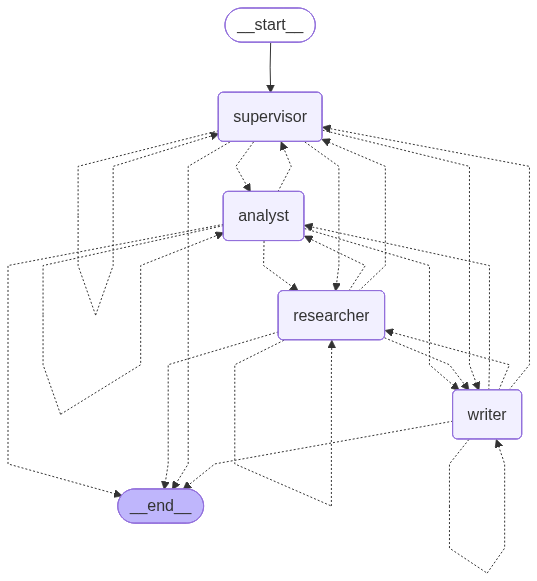

In [67]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
graph
    

In [68]:
response=graph.invoke({"messages" : [HumanMessage(content="What are the benefits and risks of AI?")]})

researcher
analyst
analyst
writer
writer


In [69]:
print(response.keys())

dict_keys(['messages', 'next_agent', 'research_data', 'analysis', 'final_report', 'task_complete', 'current_task'])


In [71]:
response['final_report']

"\n📄 FINAL REPORT\n==================================================\nGenerated: 2025-10-12 12:24\nTopic: 📊 Analyst: I've completed the analysis.\n\nTop insights:\n## 1️⃣ Key Insights & Patterns\n\n| Theme | What the data tells us | Why it matters |\n|-------|------------------------|----------------|\n| **Rapid Scale‑up of AI Capabilities** | 2010‑2024 saw *exponential* growth in model size, compute & data. Foundation models now dominate (GPT‑4, Claude, LLaMA‑2). | The “AI arms race” means any competitive edge hinges on early adoption and continuous up‑skilling...\n==================================================\n\n**Executive Report – AI Landscape 2010‑2024**  \n*Prepared for: Senior Leadership Team*  \n*Date: 12\u202fOct\u202f2025*  \n\n---\n\n## 1. Executive Summary  \n\nFrom 2010 to 2024 the AI sector has transitioned from niche research to a core business capability. Model sizes, compute budgets and data volumes have grown **exponentially**, enabling foundation models (GPT‑4,

In [ ]:
# Utilities to gracefully stop / cancel runs and compile a shutdown workflow
from langgraph.types import Command


def cancel_interrupted_run(graph, config, cancel_text="__CANCEL__"):
    """Resume any interrupted human_assistance with a cancel token so the run completes.

    - graph: compiled StateGraph (final_workflow or graph)
    - config: same config used when starting the run (e.g., {"configurable": {"thread_id": "1"}})
    - cancel_text: string passed back to the interrupted tool; you can use a special token
                   that your tool understands as a cancellation.

    This will stream the resumed events and return the final state/event list.
    """
    cmd = Command(resume={"data": cancel_text})
    events = list(graph.stream(cmd, config, stream_mode="values"))
    # print last messages for convenience
    for e in events:
        if "messages" in e:
            try:
                e["messages"][-1].pretty_print()
            except Exception:
                print(e["messages"][-1])
    return events


def compile_shutdown_workflow():
    """Return a tiny StateGraph that immediately finishes. Use this to replace a running
    workflow if you want an explicit no-op that ends immediately.

    Returns the compiled graph.
    """
    from langgraph.graph import START, END, MessagesState
    from langgraph.graph.state import StateGraph

    def shutdown_agent(state: MessagesState):
        return {"messages": [AIMessage(content="Workflow shutdown: no further action taken.")],
                "next_agent": "end",
                "task_complete": True}

    shutdown_builder = StateGraph(MessagesState)
    shutdown_builder.add_node("shutdown", shutdown_agent)
    shutdown_builder.set_entry_point("shutdown")
    shutdown_builder.add_edge("shutdown", END)
    return shutdown_builder.compile()


# Example usage (uncomment to run):
# events = cancel_interrupted_run(final_workflow, {"configurable": {"thread_id": "1"}})
# shutdown_graph = compile_shutdown_workflow()
# shutdown_graph.invoke({"messages": [HumanMessage(content="shutdown") ]})


In [ ]:
def human_review_agent(state: AgentState):
    """Human-in-the-loop node that calls human_assistance (interrupt) and executes the chosen tool.

    Expected behavior:
    - Read the preview/human_prompt from state (set by researcher_agent).
    - Call human_assistance(prompt + preview) which interrupts and waits for a human Command to resume.
    - On resume, human_assistance returns the human reply string (e.g., 'arxiv' or 'tavily').
    - Validate the reply, run the chosen tool exactly once, and return research_data + used_tool.
    """

    # Read context
    task = state.get("current_task", "research topic")
    preview = state.get("research_data", "")
    human_prompt = state.get("human_prompt", "Please reply with 'arxiv' or 'tavily'.")

    # Ensure human_assistance exists
    try:
        # call the human assistance tool which will interrupt and wait for a Command to resume
        human_choice = human_assistance(human_prompt + "\n\nPreliminary results:\n" + preview[:500])
    except Exception as e:
        return {"messages": [AIMessage(content=f"Human assistance tool error: {e}")], "next_agent": "writer"}

    # Validate human_choice
    choice_text = (human_choice or "").strip().lower()
    if not choice_text:
        return {"messages": [AIMessage(content="No human reply received. Please provide 'arxiv' or 'tavily'.")], "next_agent": "human_review"}

    if "arxiv" in choice_text:
        choice = "arxiv"
    elif "tavily" in choice_text:
        choice = "tavily"
    else:
        # ambiguous reply, ask for clarification once
        return {"messages": [AIMessage(content="I didn't understand. Please reply with exactly 'arxiv' or 'tavily'.")], "next_agent": "human_review"}

    # Execute the chosen tool once
    try:
        if choice == "arxiv":
            results = arxiv_search(task, max_results=3)
        else:
            reviewer = llm.bind_tools([search_web])
            res = reviewer.invoke([HumanMessage(content=task)])
            results = getattr(res, "content", str(res))
    except Exception as e:
        results = f"Tool execution failed: {e}"

    return {
        "messages": [AIMessage(content=f"🔎 Human review ({choice}): Research complete.\n\n{results[:800]}")],
        "research_data": results,
        "used_tool": choice,
        "next_agent": "writer"
    }

### Run & resume helper cells

The next two code cells help demonstrate the human-in-the-loop interrupt inside the notebook.

1) Start the researcher flow: this cell will start the flow and stream events until it hits the `human_assistance` interrupt — the preview and the human prompt will be printed when the interrupt occurs.

2) Resume the paused run: after the previous cell pauses, use the resume cell to send a Command with your choice (e.g., `arxiv` or `tavily`).

Run the "Start" cell first, then when it pauses run the "Resume" cell to continue.